# Subset ATAC-seq data from Furlong lab based on nanoCT time points, then sample the data, leaving 120k cells in total

In [1]:
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import snapatac2 as snap

## Read in data from fragments files, remove unnecessary obsm, write to h5ad
Files location (accessible as of 2025-01-10): [link](https://shendure-web.gs.washington.edu/content/members/DEAP_website/public/ATAC/revision/fragment_files/)


Import is handled by snapatac2, computing job used to run this notebook had these requests: 256 Gb RAM, 12 cores, 4 hours.

In [5]:
#Chromosome sizes
dm6={"chrX":23542271,
"chr2L":23513712,
"chr2R":25286936,
"chr3L":28110227,
"chr3R":32079331,
"chr4":1348131,
"chrY":3667352,
"chrM":19524}

In [7]:
atac0610 = snap.pp.import_data('../exp1_hrs06-10_b1.fragments.txt.gz', chrom_sizes=dm6, sorted_by_barcode=False)
snap.pp.add_tile_matrix(atac0610, bin_size=5000, inplace=True)

In [4]:
atac0610 = toolkit.load.fragments(
    '../exp1_hrs06-10_b1.fragments.txt.gz',
    genome_dict=dm6,
    ignore_missing_chr=True
    )

Info: Reading fragments file with 1281353320 lines...
Info: Number of unique barcodes is 10741299...


  0%|          | 0/3204 [00:00<?, ?it/s]

TypeError: unsupported operand type(s) for /: 'str' and 'float'

In [8]:
del atac0610.obsm['fragment_paired']

In [10]:
atac0812 = snap.pp.import_data('../exp1_hrs08-12_b1.fragments.txt.gz', chrom_sizes=dm6, sorted_by_barcode=False)
snap.pp.add_tile_matrix(atac0812, bin_size=5000, inplace=True)

In [12]:
del atac0812.obsm['fragment_paired']

In [13]:
atac0610.write_h5ad("../h5ad/atac0610.h5ad")

In [14]:
atac0812.write_h5ad("../h5ad/atac0812.h5ad")

In [15]:
atac1014 = snap.pp.import_data('../exp1_hrs10-14_b1.fragments.txt.gz', chrom_sizes=dm6, sorted_by_barcode=False)
snap.pp.add_tile_matrix(atac1014, bin_size=5000, inplace=True)

In [16]:
del atac1014.obsm['fragment_paired']

In [17]:
atac1014.write_h5ad("../h5ad/atac1014.h5ad")

In [18]:
atac1216 = snap.pp.import_data("../exp1_hrs12-16_b1.fragments.txt.gz", chrom_sizes=dm6, sorted_by_barcode=False)

In [19]:
snap.pp.add_tile_matrix(atac1216, bin_size=5000, inplace=True)

In [20]:
del atac1216.obsm['fragment_paired']

In [21]:
atac1216.write_h5ad("../h5ad/atac1216.h5ad")

In [22]:
mddf = pd.read_csv('../meta/metad_all_atac.csv').set_index('cell')

### Subset based on metadata csv

In [23]:
atac0610 = atac0610[atac0610.obs.index.isin(mddf.index)]

In [24]:
atac0812 = atac0812[atac0812.obs.index.isin(mddf.index)]

In [25]:
atac1014 = atac1014[atac1014.obs.index.isin(mddf.index)]

In [26]:
atac1216 = atac1216[atac1216.obs.index.isin(mddf.index)]

### Add obs columns from metadata

In [34]:
time=mddf['NNv1_time.new'].to_dict()
labels = mddf['refined_annotation'].to_dict()
age = mddf['NNv1_age'].to_dict()


In [28]:
atac0610.obs['label']=[labels[a] for a in atac0610.obs.index]
atac0610.obs['NN_time']=[time[a] for a in atac0610.obs.index]
atac0610.obs['NN_age']=[age[a] for a in atac0610.obs.index]

atac0812.obs['label']=[labels[a] for a in atac0812.obs.index]
atac0812.obs['NN_time']=[time[a] for a in atac0812.obs.index]
atac0812.obs['NN_age']=[age[a] for a in atac0812.obs.index]

atac1014.obs['label']=[labels[a] for a in atac1014.obs.index]
atac1014.obs['NN_time']=[time[a] for a in atac1014.obs.index]
atac1014.obs['NN_age']=[age[a] for a in atac1014.obs.index]

atac1216.obs['label']=[labels[a] for a in atac1216.obs.index]
atac1216.obs['NN_time']=[time[a] for a in atac1216.obs.index]
atac1216.obs['NN_age']=[age[a] for a in atac1216.obs.index]

/tmp/52376677/ipykernel_3343726/1854698543.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  atac0610.obs['label']=[labels[a] for a in atac0610.obs.index]
/tmp/52376677/ipykernel_3343726/1854698543.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  atac0812.obs['label']=[labels[a] for a in atac0812.obs.index]
/tmp/52376677/ipykernel_3343726/1854698543.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  atac1014.obs['label']=[labels[a] for a in atac1014.obs.index]
/tmp/52376677/ipykernel_3343726/1854698543.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  atac1216.obs['label']=[labels[a] for a in atac1216.obs.index]


In [32]:
timerange=['08-10', '10-12', '12-14', '14-16']
atac0610 = atac0610[atac0610.obs['NN_time'].isin(timerange)]
atac0812 = atac0812[atac0812.obs['NN_time'].isin(timerange)]
atac1014 = atac1014[atac1014.obs['NN_time'].isin(timerange)]
atac1216 = atac1216[atac1216.obs['NN_time'].isin(timerange)]

In [31]:
mddf

,doublet_score,exp,time,sample,seurat_clusters,lasso_age,NNv1_age,lasso_time.new,NNv1_time.new,seurat_clusters.predtime,refined_annotation
cell,,,,,,,,,,,
CTATGGTTCGTTCCATTCTTTCTCATTGCCCTCTGCGATC,0.802721,exp1,03-07,exp1_hrs03-07_b1,7,-3.110988,1.690188,00-02,00-02,3,Blastoderm
AGATAATTCCTTCCATTCTTAGTCGCGTCGAAGTTCGCTG,0.700680,exp1,03-07,exp1_hrs03-07_b1,6,-1.039036,1.330054,00-02,00-02,1,Blastoderm
TCCTCTTAACCTAGCTTCTTGTAGTAGTCCTGATTCTCGT,0.505102,exp1,03-07,exp1_hrs03-07_b1,1,-3.924070,1.984080,00-02,00-02,1,Blastoderm
ACGGCAAGCAATATCTTCCGGAGCTCAGCCCCTACTCAAC,0.653061,exp1,03-07,exp1_hrs03-07_b1,1,2.537512,1.861791,02-04,00-02,2,Blastoderm
AACTTACGCTCATTCTGATGCCAATTCCATGTCGTTCGCC,0.671769,exp1,03-07,exp1_hrs03-07_b1,1,-1.401258,1.801240,00-02,00-02,2,Blastoderm
...,...,...,...,...,...,...,...,...,...,...,...
ACGTCTCCTCTAATTCCGGTGGCAATCAAGATTCATCGCC,0.578947,exp2,16-20,exp2_hrs16-20_b1,1,16.530663,18.050606,16-18,18-20,1,Pharnyx
GTAATCGCAATCAACGAGGTGCCAAGGCAACCGATACTCT,0.438596,exp2,16-20,exp2_hrs16-20_b1,1,13.830964,18.161829,12-14,18-20,2,Epidermis
TCTCAGCGGCTTCTCTACGATGGCCGTCTTTTGCATGAGG,0.485380,exp2,16-20,exp2_hrs16-20_b1,6,13.637865,18.004314,12-14,18-20,0,Somatic muscle


In [38]:
atac0610.obs.sort_values('NN_age', ascending=False)

,n_fragment,frac_dup,frac_mito,label,NN_time,NN_age
CATCGACTCATCGGAGTATGAATATAGCGGAGAATCCTCG,1245,0.224098,0.066017,Midgut,14-16,15.982351
TTCCGCGTTAAAGATCAGTTGGCAGCAGTTATAGGTCCAA,744,0.279886,0.019763,Hindgut,14-16,15.954950
TTCCGCGTTAAGTCTTAATTGATAGCCGATTTCTGCAAGA,2668,0.252774,0.033683,Ventral nerve cord,14-16,15.925406
ACTCCGACCATTCCATTCTTAGTCGCGTCGCCATTAGCAG,12176,0.256341,0.011287,Ventral nerve cord,14-16,15.910919
GTCATCGACCGCAGCTGATTTGGACCAAGGTGGATCAGGC,3946,0.261220,0.021572,Epidermis,14-16,15.907127
...,...,...,...,...,...,...
TTCTATAGTTCTGACTACTTGGCAGCAGTTTGCTGCCGGA,1055,0.319197,0.293369,Epidermis prim.,08-10,8.000263
AATTAACCATTGGATCGTTATAAGTAAGTAAATAAGGCTC,1714,0.254910,0.038699,Ventral nerve cord prim.,08-10,8.000219
GTTCGGCCTTGGAGAATGGCTTAGCGGAACTTCTCAGTCA,6746,0.228451,0.055579,Ventral nerve cord prim.,08-10,8.000205
AGCTGCCTCAGCTTACTATAAATATAGCGGGGCATGGCCA,43089,0.248702,0.026963,Muscle prim.,08-10,8.000154


In [39]:
atacad = ad.concat([atac0610, atac0812, atac1014, atac1216])

In [40]:
atacad

AnnData object with n_obs × n_vars = 345419 × 26779
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'label', 'NN_time', 'NN_age'

In [42]:
atacad.write_h5ad("../h5ad/atac_06_16h_concat.h5ad")

... storing 'label' as categorical
... storing 'NN_time' as categorical


## Subset ATAC, leaving 30k cells for each time point

In [43]:
samples = [atacad.obs[atacad.obs['NN_time']==a].sample(n=30000, random_state=2).index for a in atacad.obs['NN_time'].unique()]
samples = np.array([list(s) for s in samples])

In [44]:
atacad_s=atacad[atacad.obs.index.isin(samples.flatten())]

In [ ]:
atacad_s.write_h5ad("../h5ad/atac_120k_subset.h5ad")

## Run UMAP, it's not going to be used at any point later, therefore not required

In [46]:
atacad.obs['cell'] = [(l[:-6] if (l[-5:] == 'prim.') else l) for l in atacad.obs['label']]

In [47]:
snap.tl.spectral(atacad, features=None)

In [48]:
atacad.obs['total_counts']=np.array(atacad.X.sum(axis=1))[:,0]
atacad.obs['log_total_counts']=np.log1p(atacad.obs['total_counts'])

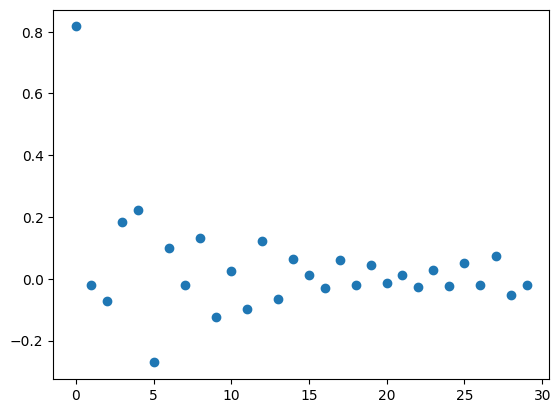

In [49]:
import scipy.stats as sts
import matplotlib.pyplot as plt

def depth_corr(_data,rep):
  pers=[]
  for s in range(_data.obsm[rep].shape[1]):
    arr=_data.obsm[rep][:,s]
    pers.append(sts.pearsonr(_data.obs['total_counts'], arr))
  plt.scatter(range(_data.obsm[rep].shape[1]), [p.statistic for p in pers])


depth_corr(atacad,'X_spectral')

In [50]:
atacad.obsm['X_new']=np.delete(atacad.obsm['X_spectral'],0,axis=1)

In [51]:
sc.pp.neighbors(atacad,use_rep='X_new')
sc.tl.umap(atacad)

/home/artem/miniconda3/envs/singlecell2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


... storing 'cell' as categorical


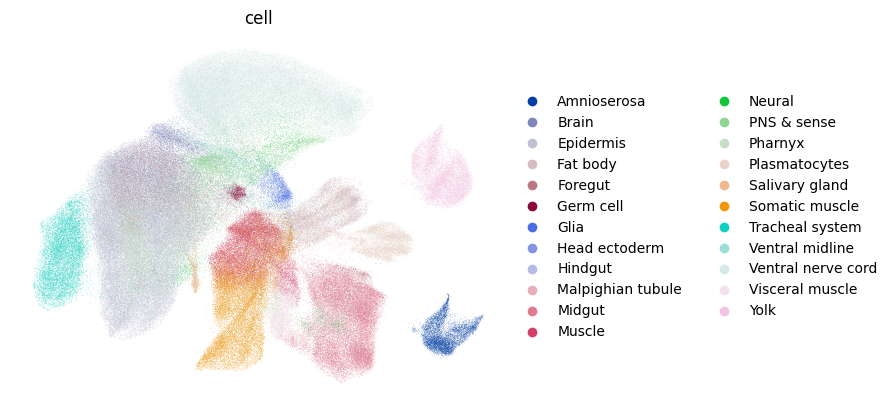

<Figure size 640x480 with 0 Axes>

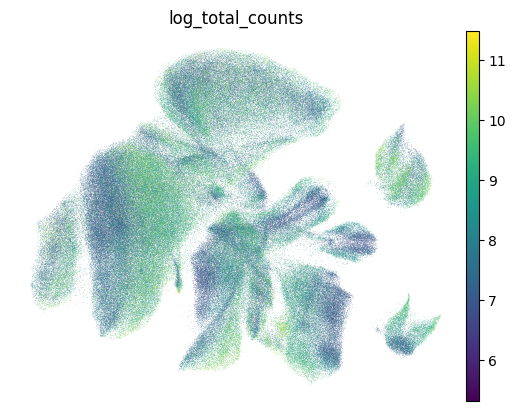

In [52]:
sc.pl.umap(atacad, color='cell',frameon=False)

plt.set_cmap('viridis')
sc.pl.umap(atacad, color='log_total_counts',frameon=False)

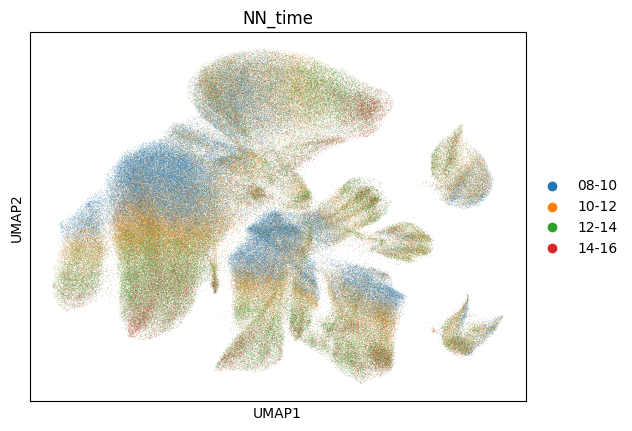

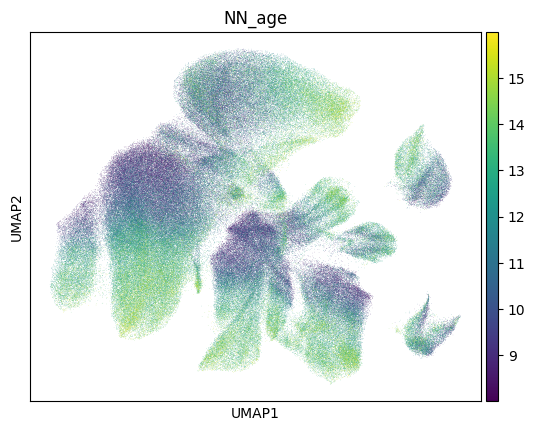

In [54]:
sc.pl.umap(atacad, color = "NN_time")
sc.pl.umap(atacad, color = "NN_age")

/tmp/52376677/ipykernel_3343726/3612177368.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(atacad, resolution=1)


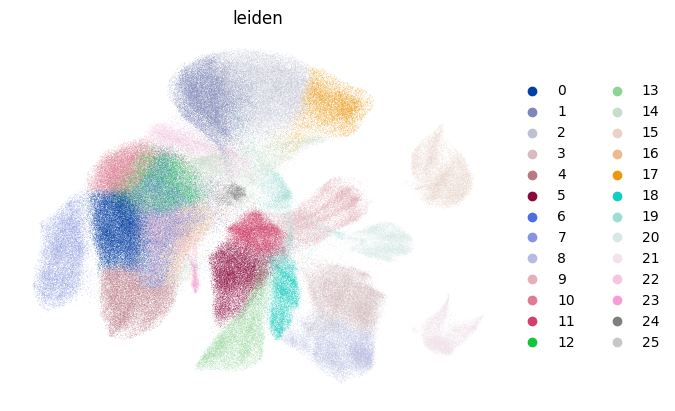

In [55]:
sc.tl.leiden(atacad, resolution=1)
sc.pl.umap(atacad, color='leiden',frameon=False)

In [56]:
# atacad.write_h5ad("../h5ad/atac_06_16h_concat_full_umap.h5ad")